**#Titanic: Machine Learning from Disaster (EDA)**
**Objective:** To perform an Exploratory Data Analysis on the Titanic passenger manifest and identify the key factors (Social Class, Age, Gender) that influenced survival rates.

**Key Skills**: Handling missing data, Feature Engineering, and Multivariate Visualization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import style
style.use('ggplot')
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [4]:
tdata=pd.read_csv('/content/train.csv')
tdata.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
tdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
tdata.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Sex,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [ ]:
print('survived : ', tdata.Survived.unique())
print('pclass : ', tdata.Pclass.unique())
print('Gender : ', tdata.Sex.unique())
print('Embarked : ', tdata.Embarked.dropna().unique())

survived :  [0 1]
pclass :  [3 1 2]
Gender :  ['male' 'female']
Embarked :  ['S' 'C' 'Q']


In [ ]:
# duplicate value
tdata.duplicated().sum()

np.int64(0)

In [ ]:
#missing value
tdata.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**##Handling Missing Values**

**Age:** I am using the Median to fill missing values because the distribution is slightly skewed.

**Embarked** : I will use the Mode (most frequent value) as there are only 2 missing entries.

**Cabin:** Dropping this column as over 70% of the data is missing, making it unreliable for analysis

In [5]:
tdata['Age'].fillna(tdata['Age'].mean(), inplace=True)


In [6]:
tdata.drop('Cabin', axis = 1,inplace=True)

In [7]:
tdata['Embarked'].fillna(tdata['Embarked'].mode()[0], inplace=True)
tdata.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
tdata.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,C


In [9]:
tdata.Survived.value_counts()

,count
Survived,
0,549
1,342


In [10]:
svl_data=tdata.Survived.value_counts(normalize=True)
print("percentage of people survived :",svl_data[1]*100)
print("percentage of people not survived :",svl_data[0]*100)

percentage of people survived : 38.38383838383838
percentage of people not survived : 61.61616161616161


<Axes: xlabel='Survived', ylabel='count'>

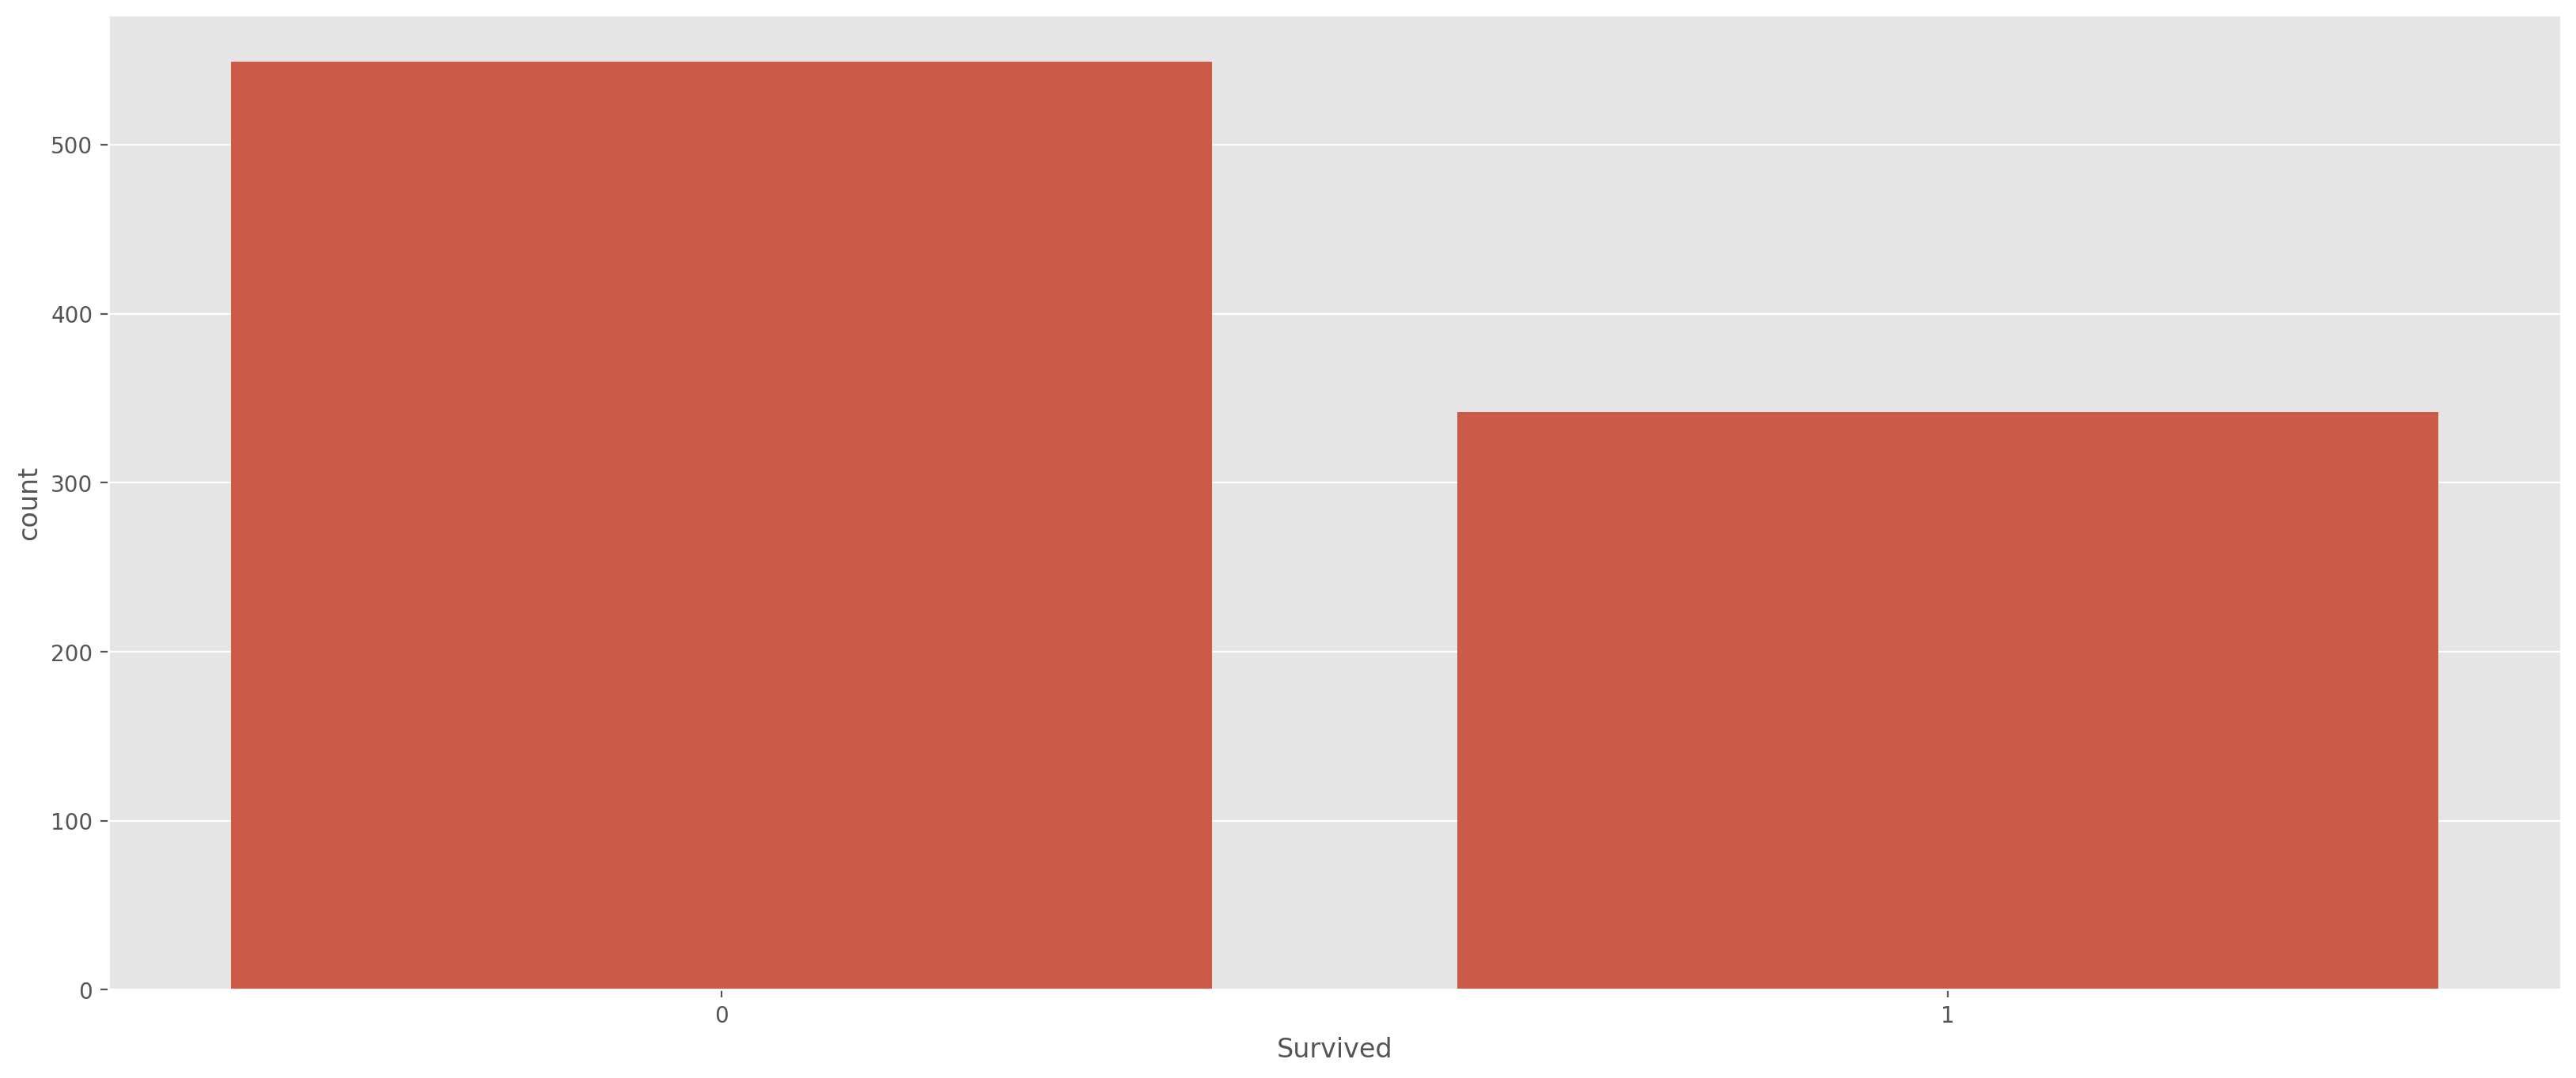

In [11]:
#count plot to show survived data
plt.figure(figsize=(20,8),dpi=200)
sns.countplot(x='Survived' , data=tdata)

In [12]:
# gender vs survival
tdata.groupby(['Sex','Survived'])['Survived'].count()
# or tdata.groupby('Sex').survived.value.count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

In [13]:
tdata.groupby('Sex')['Survived'].value_counts().unstack()

Survived,0,1
Sex,,
female,81,233
male,468,109


In [14]:
svl_gender = tdata.groupby('Sex')['Survived'].value_counts(normalize=True).sort_index()

# Use lowercase 'female' and 'male' and ensure all are in 'quotes'
print('Percentage of female survived:', svl_gender['female'][1] * 100)
print('Percentage of female not survived:', svl_gender['female'][0] * 100)
print('Percentage of male survived:', svl_gender['male'][1] * 100)
print('Percentage of male not survived:', svl_gender['male'][0] * 100)

Percentage of female survived: 74.20382165605095
Percentage of female not survived: 25.796178343949045
Percentage of male survived: 18.890814558058924
Percentage of male not survived: 81.10918544194108


<Axes: xlabel='Survived', ylabel='count'>

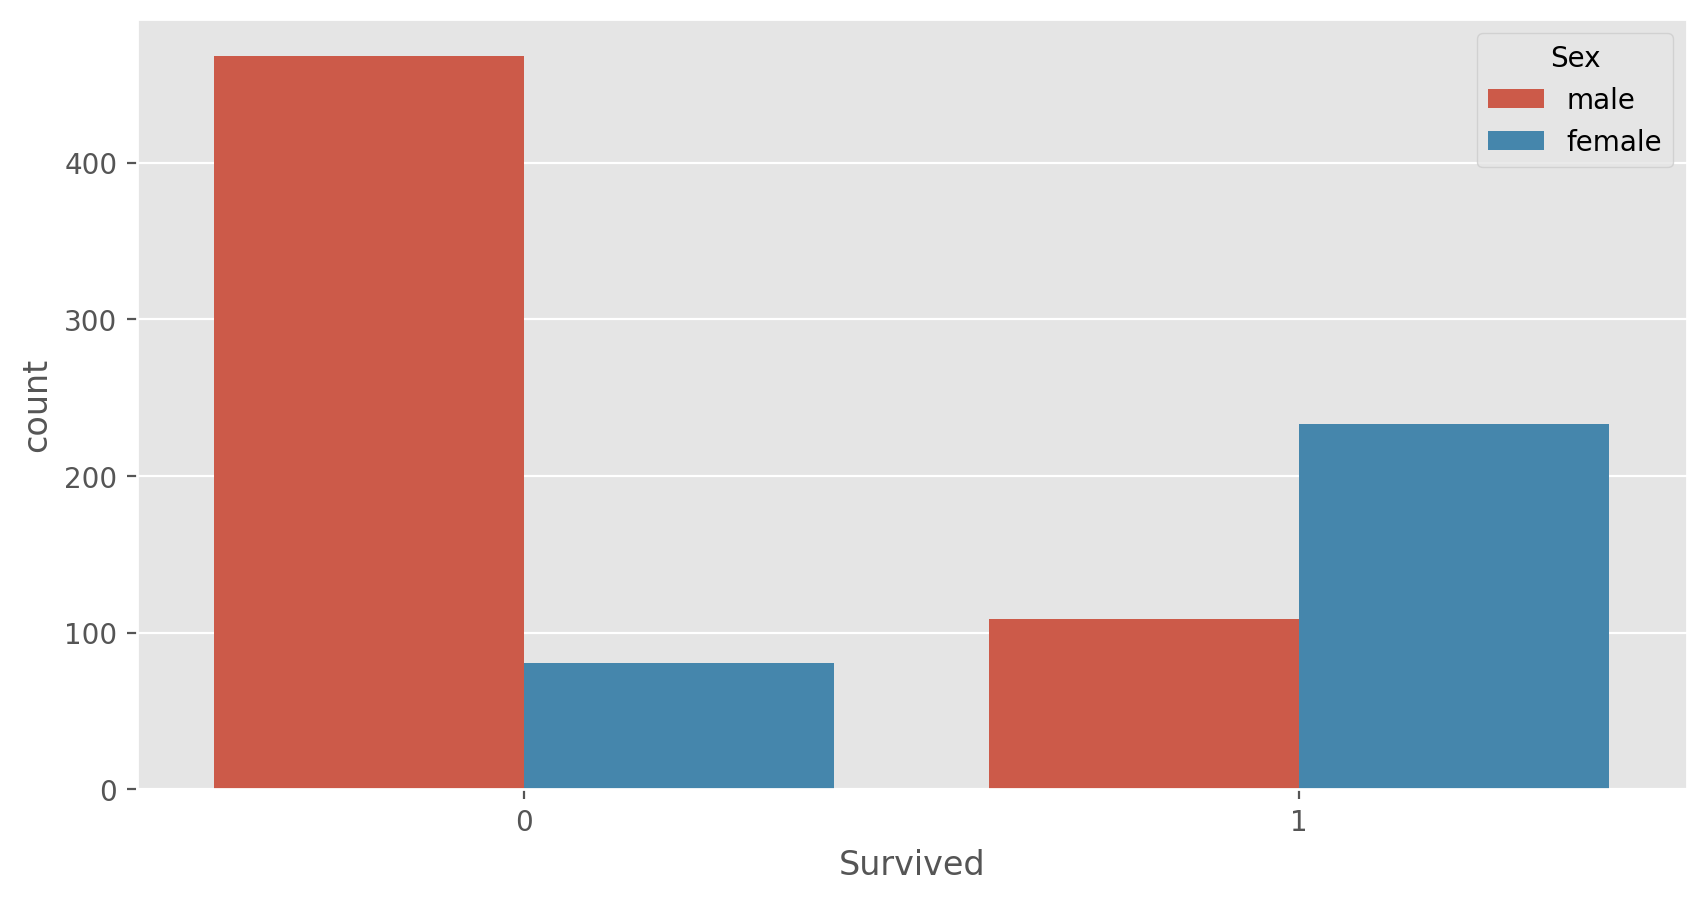

In [15]:
plt.figure(figsize=(10,5),dpi=200)
sns.countplot(x='Survived',hue='Sex' , data=tdata)

In [16]:
svl_gender


Sex     Survived
female  0           0.257962
        1           0.742038
male    0           0.811092
        1           0.188908
Name: proportion, dtype: float64

Text(0.5, 1.0, 'male survival')

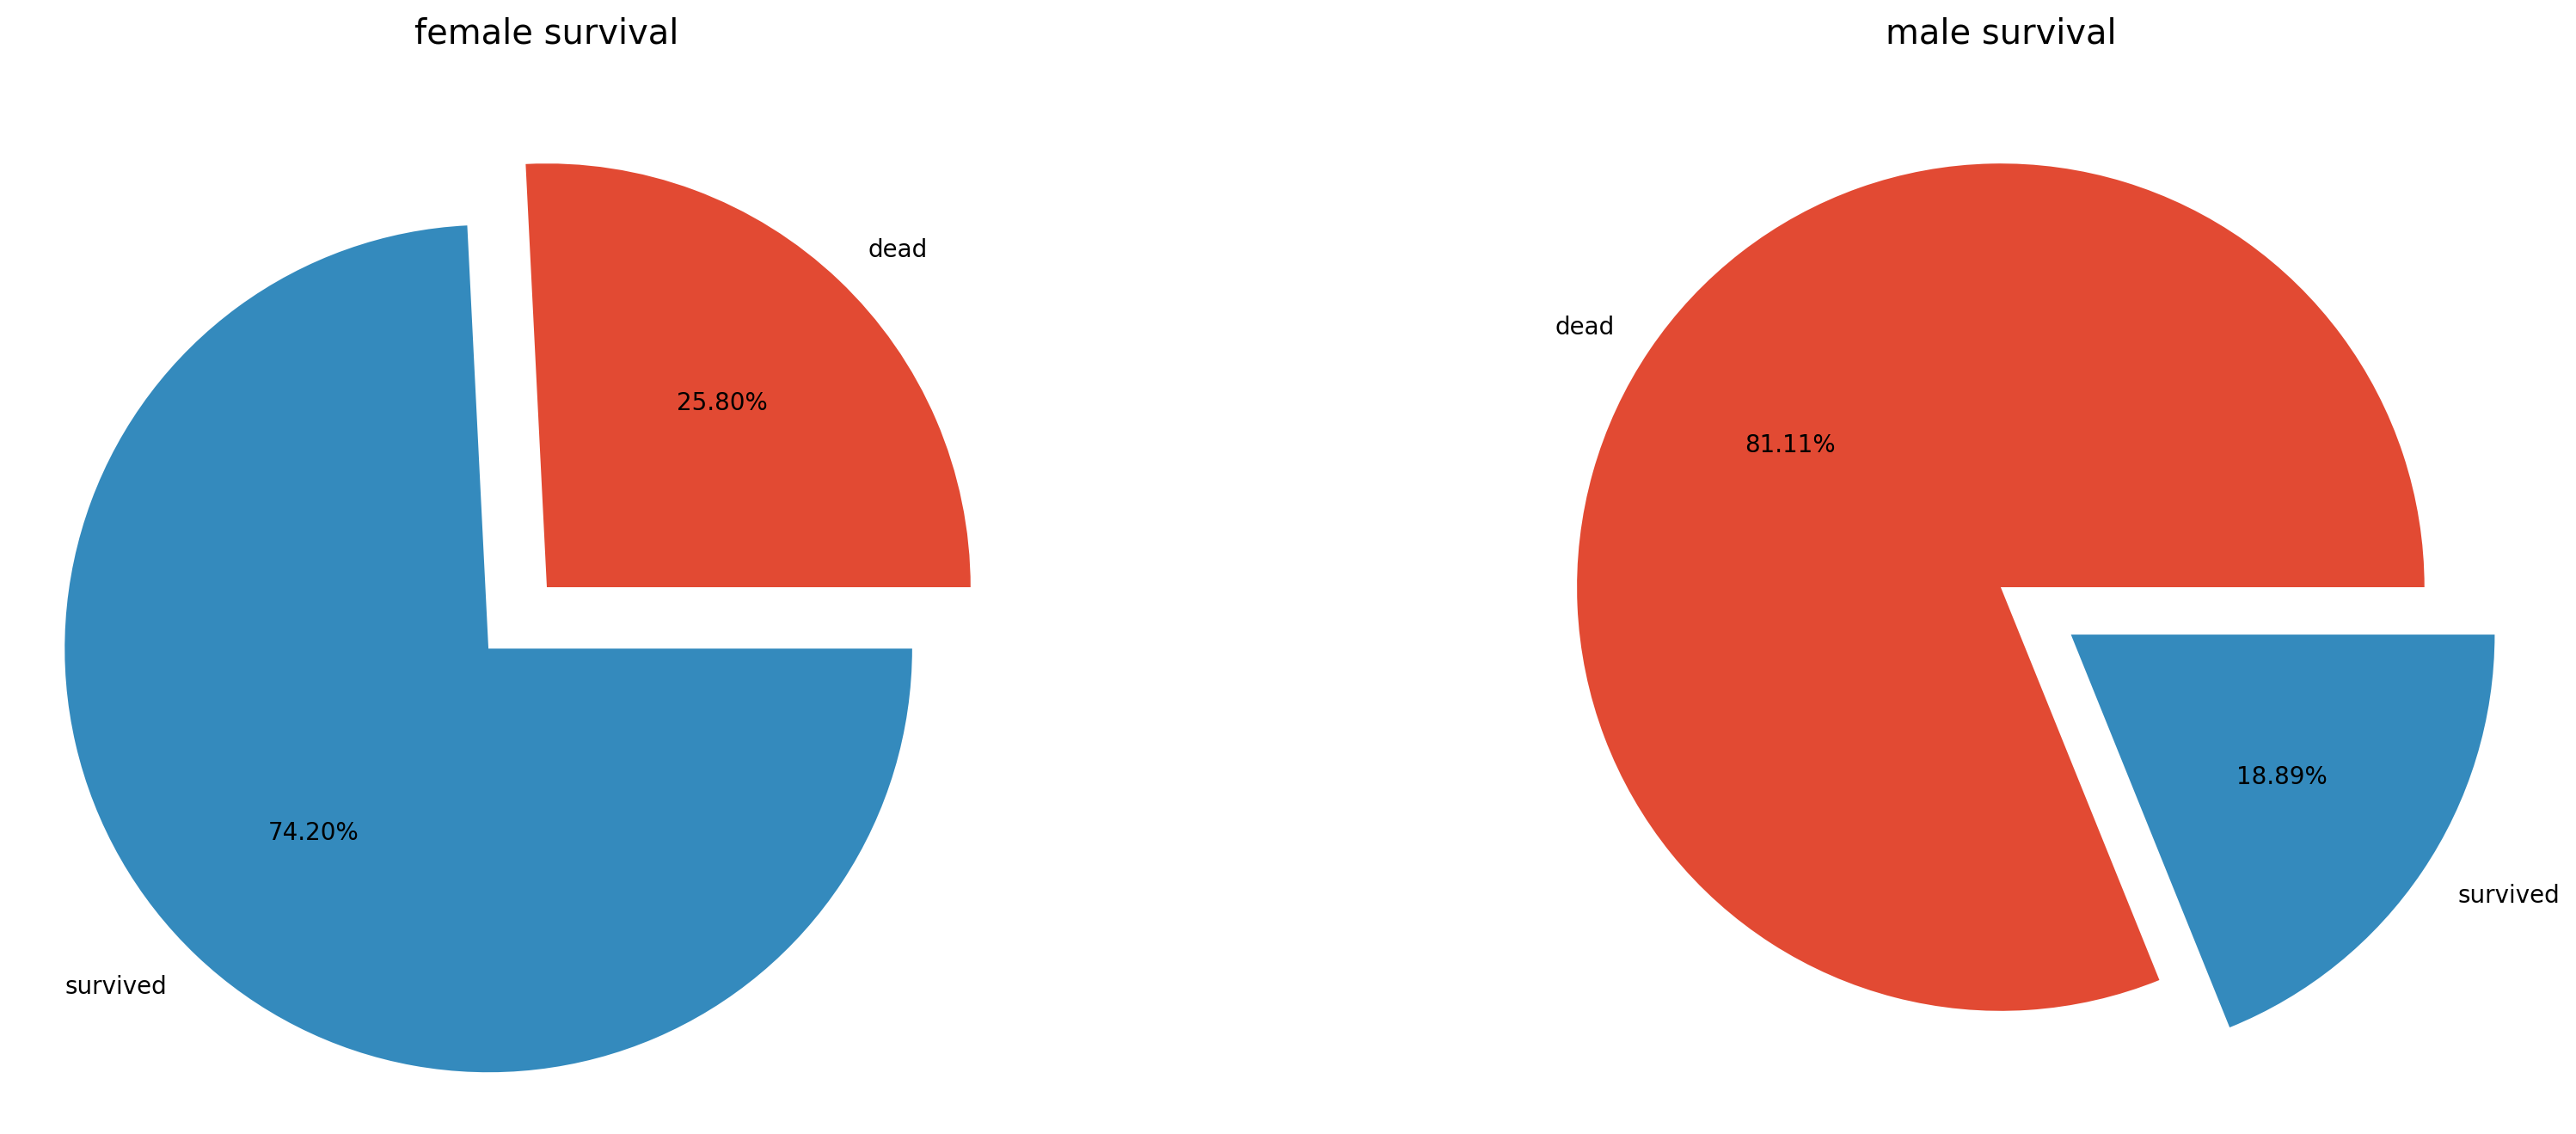

In [17]:
#pie chart of gender by survival rate
female_svl = svl_gender['female']
male_svl = svl_gender['male']
labels = ['dead' , 'survived']

plt.figure(figsize=(20,8) , dpi=200)
plt.subplot(1,2,1)
plt.pie(x=female_svl , labels=labels , autopct='%1.2f%%', explode=[0,0.2])
plt.title('female survival')

plt.subplot(1,2,2)
plt.pie(x=male_svl , labels=labels , autopct='%1.2f%%', explode=[0,0.2])
plt.title('male survival')


In [18]:
tdata.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,C


In [19]:
#passenger class and survival
pc_svl=tdata.groupby('Pclass')['Survived'].value_counts()
pc_svl

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64

In [ ]:
# 1. Calculate the normalized counts (the percentages)
# 'normalize=True' turns counts (e.g., 50 people) into decimals (e.g., 0.50)
svl_pcl = tdata.groupby('Pclass')['Survived'].value_counts(normalize=True).sort_index()

# 2. Print with the corrected parentheses and variable names
# Each line now has two closing brackets: ))
print('Percentage of survived in pclass 1:', round(svl_pcl[1][1] * 100, 2))
print('Percentage of dead in pclass 1:',     round(svl_pcl[1][0] * 100, 2))

print('Percentage of survived in pclass 2:', round(svl_pcl[2][1] * 100, 2))
print('Percentage of dead in pclass 2:',     round(svl_pcl[2][0] * 100, 2))

print('Percentage of survived in pclass 3:', round(svl_pcl[3][1] * 100, 2))
print('Percentage of dead in pclass 3:',     round(svl_pcl[3][0] * 100, 2))

Percentage of survived in pclass 1: 62.96
Percentage of dead in pclass 1: 37.04
Percentage of survived in pclass 2: 47.28
Percentage of dead in pclass 2: 52.72
Percentage of survived in pclass 3: 24.24
Percentage of dead in pclass 3: 75.76


<Axes: xlabel='Pclass', ylabel='count'>

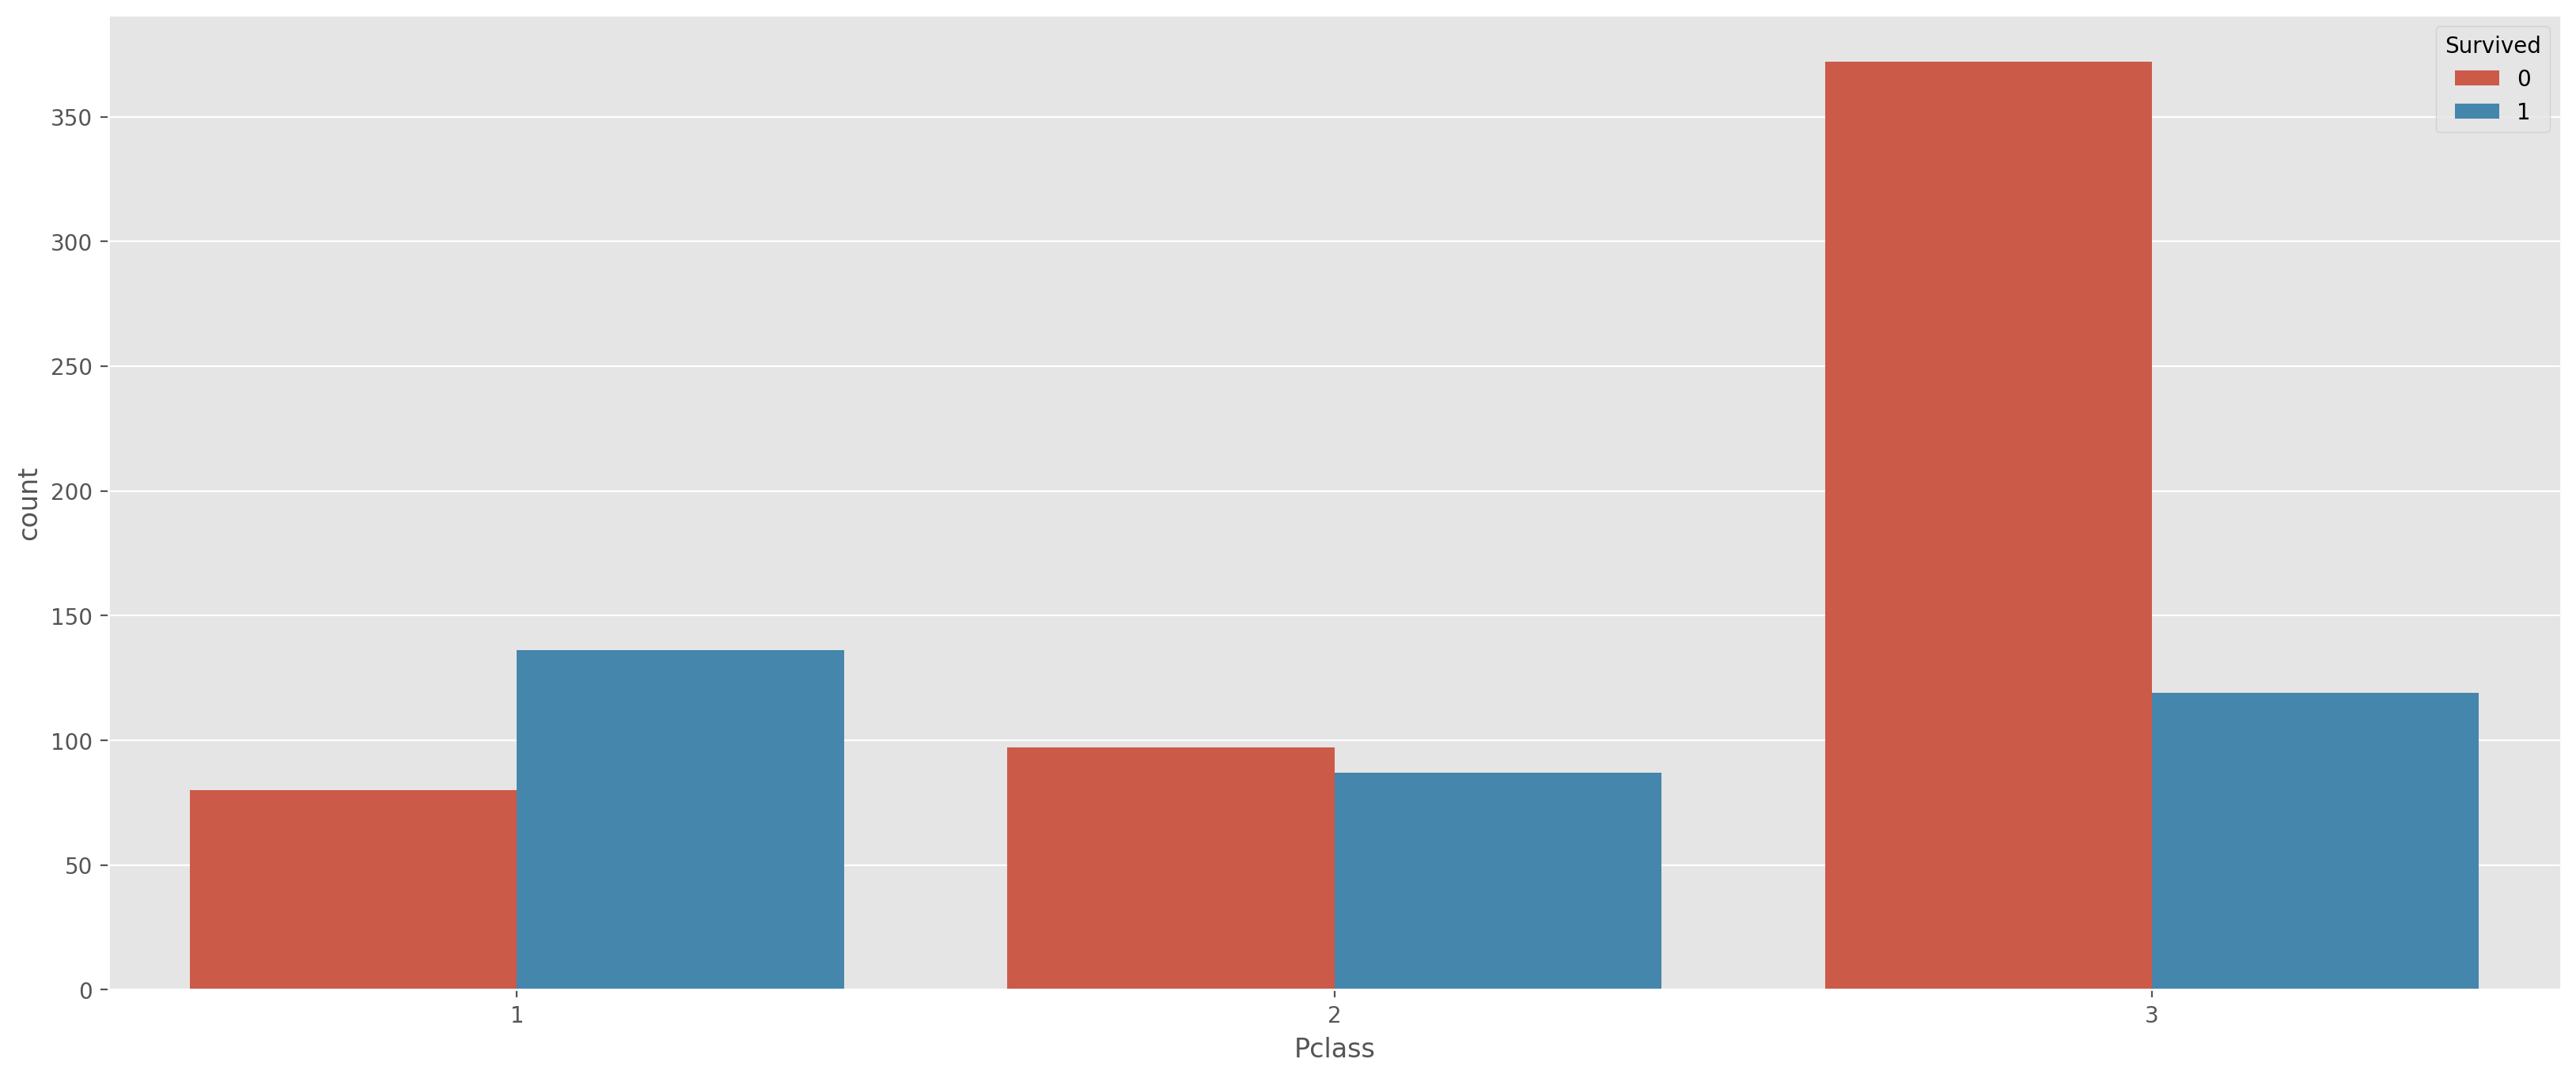

In [22]:
plt.figure(figsize=(20,8),dpi=200)
sns.countplot(x='Pclass',hue='Survived',data=tdata)

Text(0.5, 1.0, 'passenger class 3 survival')

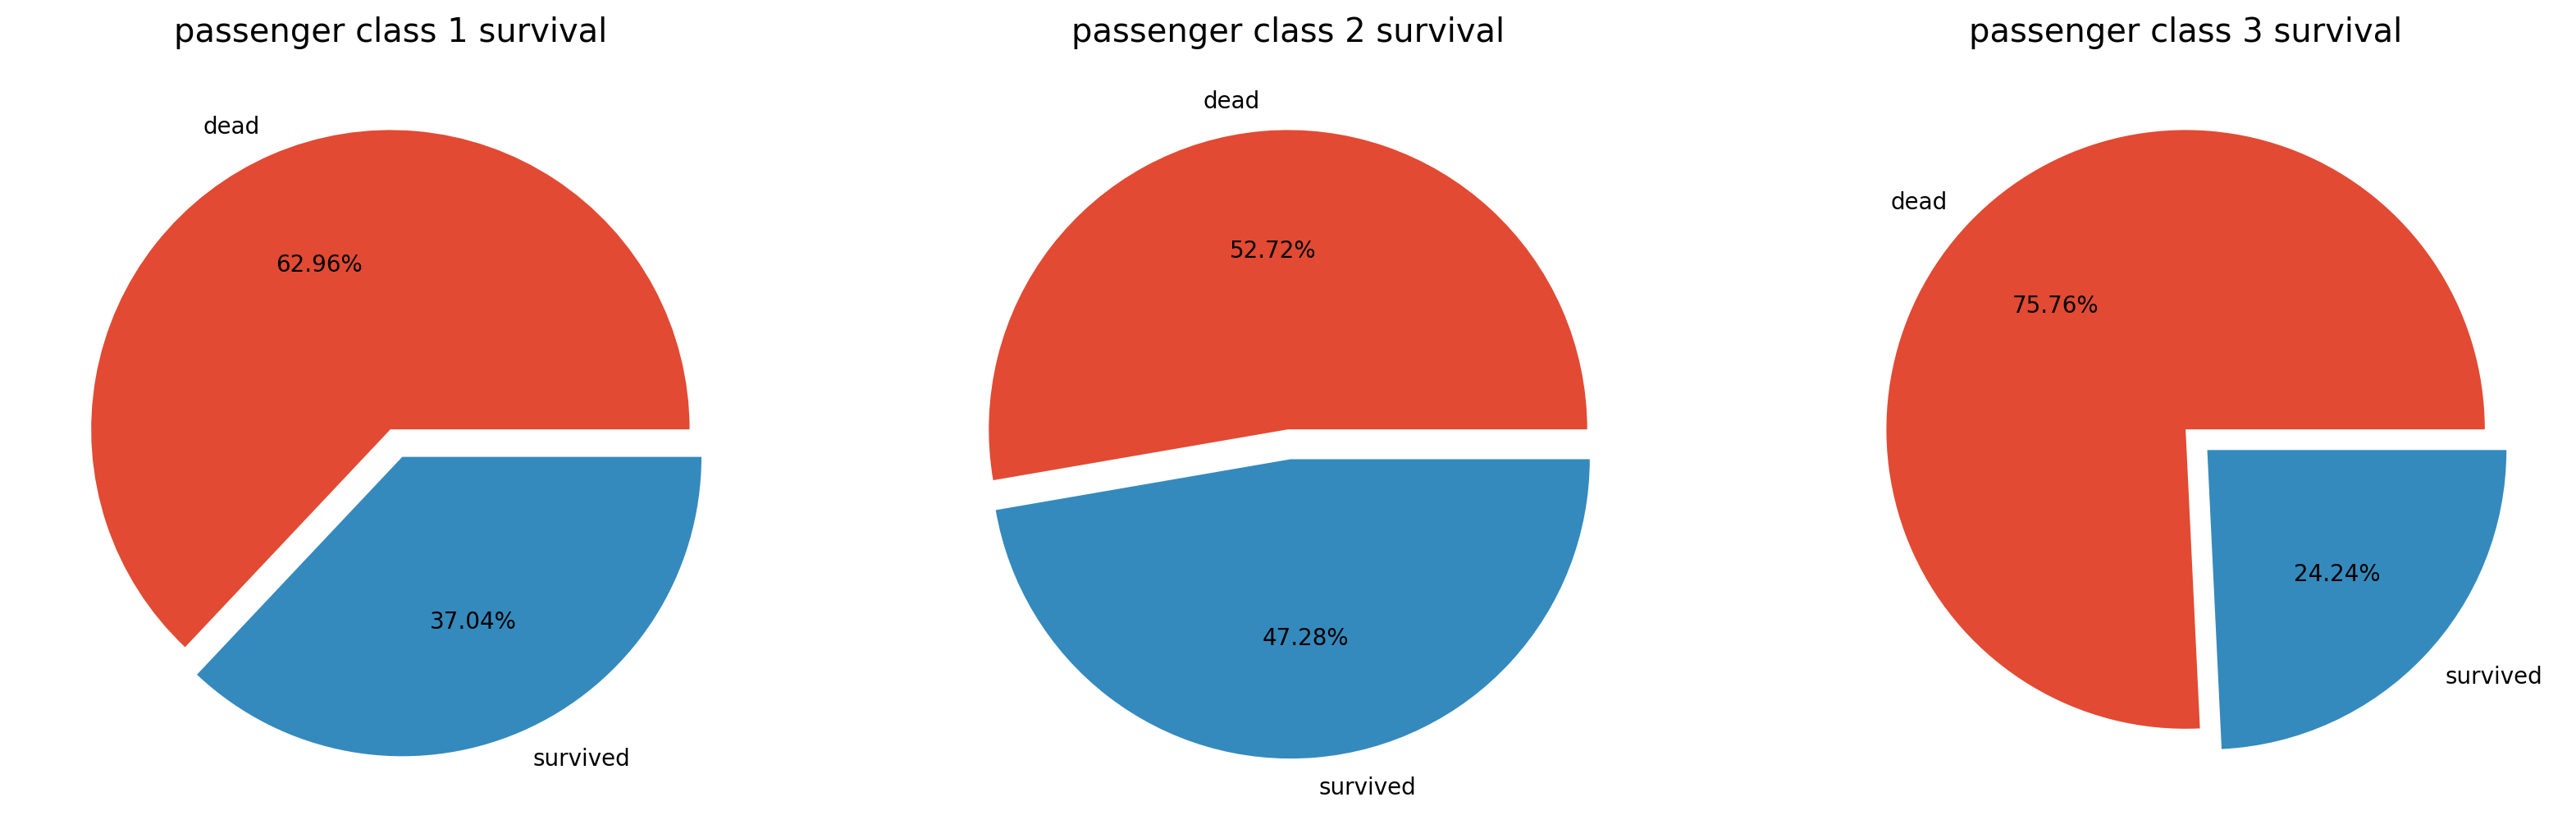

In [24]:
# correct pie chart
plt.figure(figsize=(20,8),dpi=200)
plt.subplot(1,3,1)
plt.pie(x=pc1, labels=labels, autopct='%1.2f%%', explode=[0,0.1])
plt.title('passenger class 1 survival')

plt.subplot(1,3,2)
plt.pie(x=pc2,labels=labels,autopct='%1.2f%%',explode=[0,0.1])
plt.title('passenger class 2 survival')

plt.subplot(1,3,3)
plt.pie(x=pc3,labels=labels,autopct='%1.2f%%',explode=[0,0.1])
plt.title('passenger class 3 survival')

In [ ]:
# checking gender in pclass
gen_pcl=tdata.groupby(['Pclass','Sex'])['Survived'].value_counts()
gen_pcl

Pclass  Sex     Survived
1       female  1            91
                0             3
        male    0            77
                1            45
2       female  1            70
                0             6
        male    0            91
                1            17
3       female  0            72
                1            72
        male    0           300
                1            47
Name: count, dtype: int64

In [ ]:
print('female of survived in pclass 1:', gen_pcl[1]['female'][1] )
print('female of dead in pclass 1:',     gen_pcl[1]['female'][0] )
print('male of survived in pclass 1:', gen_pcl[1]['male'][1] )
print('male of dead in pclass 1:',     gen_pcl[1]['male'][0] )

print('female of survived in pclass 2:', gen_pcl[2]['female'][1] )
print('female of dead in pclass 2:',     gen_pcl[2]['female'][0] )
print('male of survived in pclass 2:', gen_pcl[2]['male'][1] )
print('male of dead in pclass 2:',     gen_pcl[2]['male'][0] )

print('female of survived in pclass 3:', gen_pcl[3]['female'][1] )
print('female of dead in pclass 3:',     gen_pcl[3]['female'][0] )
print('male of survived in pclass 3:', gen_pcl[3]['male'][1] )
print('male of dead in pclass 3:',     gen_pcl[3]['male'][0] )


female of survived in pclass 1: 91
female of dead in pclass 1: 3
male of survived in pclass 1: 45
male of dead in pclass 1: 77
female of survived in pclass 2: 70
female of dead in pclass 2: 6
male of survived in pclass 2: 17
male of dead in pclass 2: 91
female of survived in pclass 3: 72
female of dead in pclass 3: 72
male of survived in pclass 3: 47
male of dead in pclass 3: 300


In [ ]:
fpcl1=gen_pcl[1]['female'][1]
fpcld1=gen_pcl[1]['female'][0]
mpcl1=gen_pcl[1]['male'][1]
mpcld1=gen_pcl[1]['male'][0]
fpcl2=gen_pcl[2]['female'][1]
fpcld2=gen_pcl[2]['female'][0]
mpcl2=gen_pcl[2]['male'][1]
mpcld2=gen_pcl[2]['male'][0]
fpcl3=gen_pcl[3]['female'][1]
fpcld3=gen_pcl[3]['female'][0]
mpcl3=gen_pcl[3]['male'][1]
mpcld3=gen_pcl[3]['male'][0]

labels=['dead','survived']

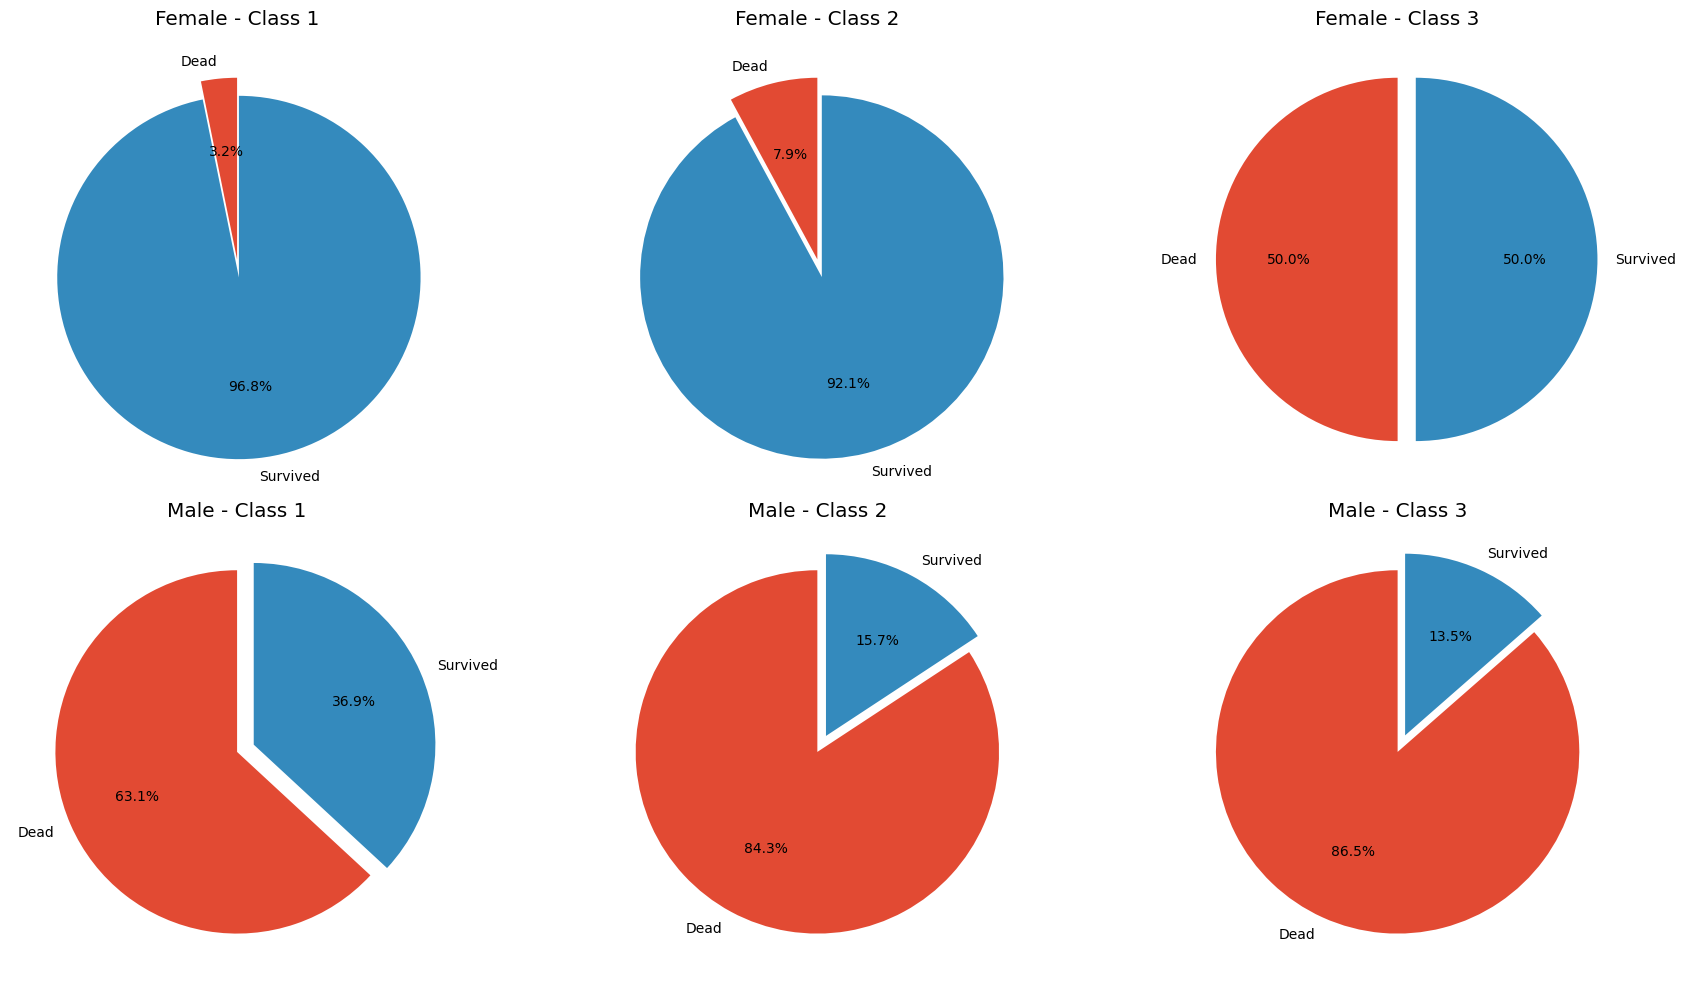

In [ ]:
import matplotlib.pyplot as plt

classes = [1, 2, 3]
genders = ['female', 'male']
labels = ['Dead', 'Survived']

# Create a figure with a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, gender in enumerate(genders):      # Row loop (0=female, 1=male)
    for j, pclass in enumerate(classes):  # Column loop (0=cl1, 1=cl2, 2=cl3)

        # Select the data: [Dead count, Survived count]
        data = [gen_pcl[pclass][gender][0], gen_pcl[pclass][gender][1]]

        # Plot in the specific subplot (row i, column j)
        axes[i, j].pie(data, labels=labels, autopct='%1.1f%%', startangle=90, explode=[0, 0.1])
        axes[i, j].set_title(f'{gender.capitalize()} - Class {pclass}')

plt.tight_layout()
plt.show()

In [ ]:
# family member and survival
tdata['family member']= tdata.SibSp + tdata.Parch

<Axes: xlabel='family member', ylabel='count'>

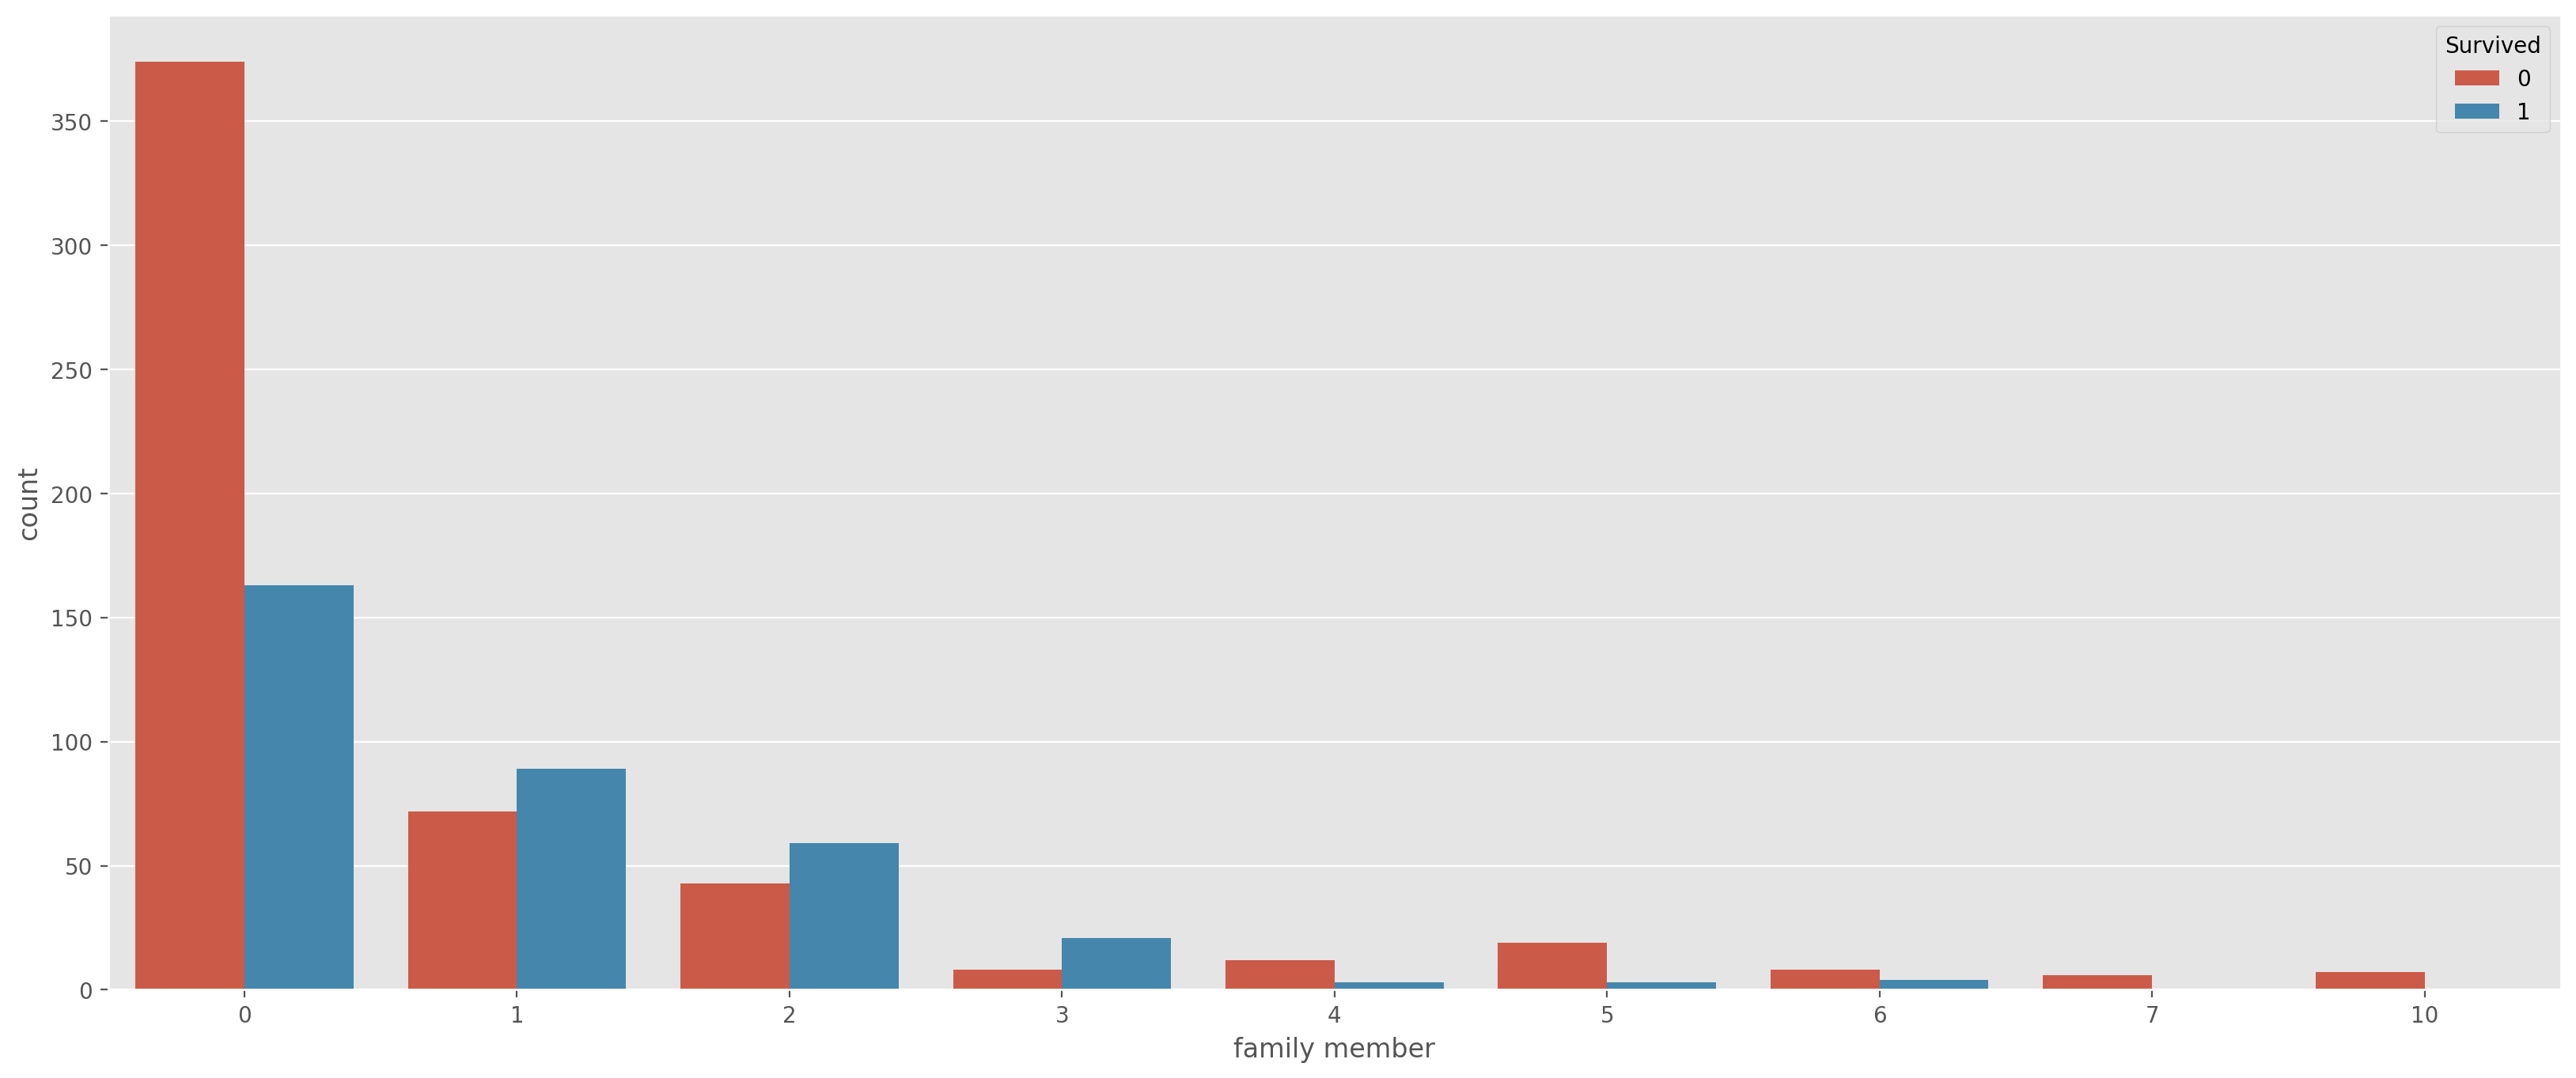

In [ ]:
plt.figure(figsize=(20,8),dpi=200)
sns.countplot(x='family member', hue='Survived',data=tdata)

In [ ]:
#fare and survival
tdata.groupby('Survived').Fare.mean()

,Fare
Survived,
0,22.117887
1,48.395408


<Axes: xlabel='Survived', ylabel='Fare'>

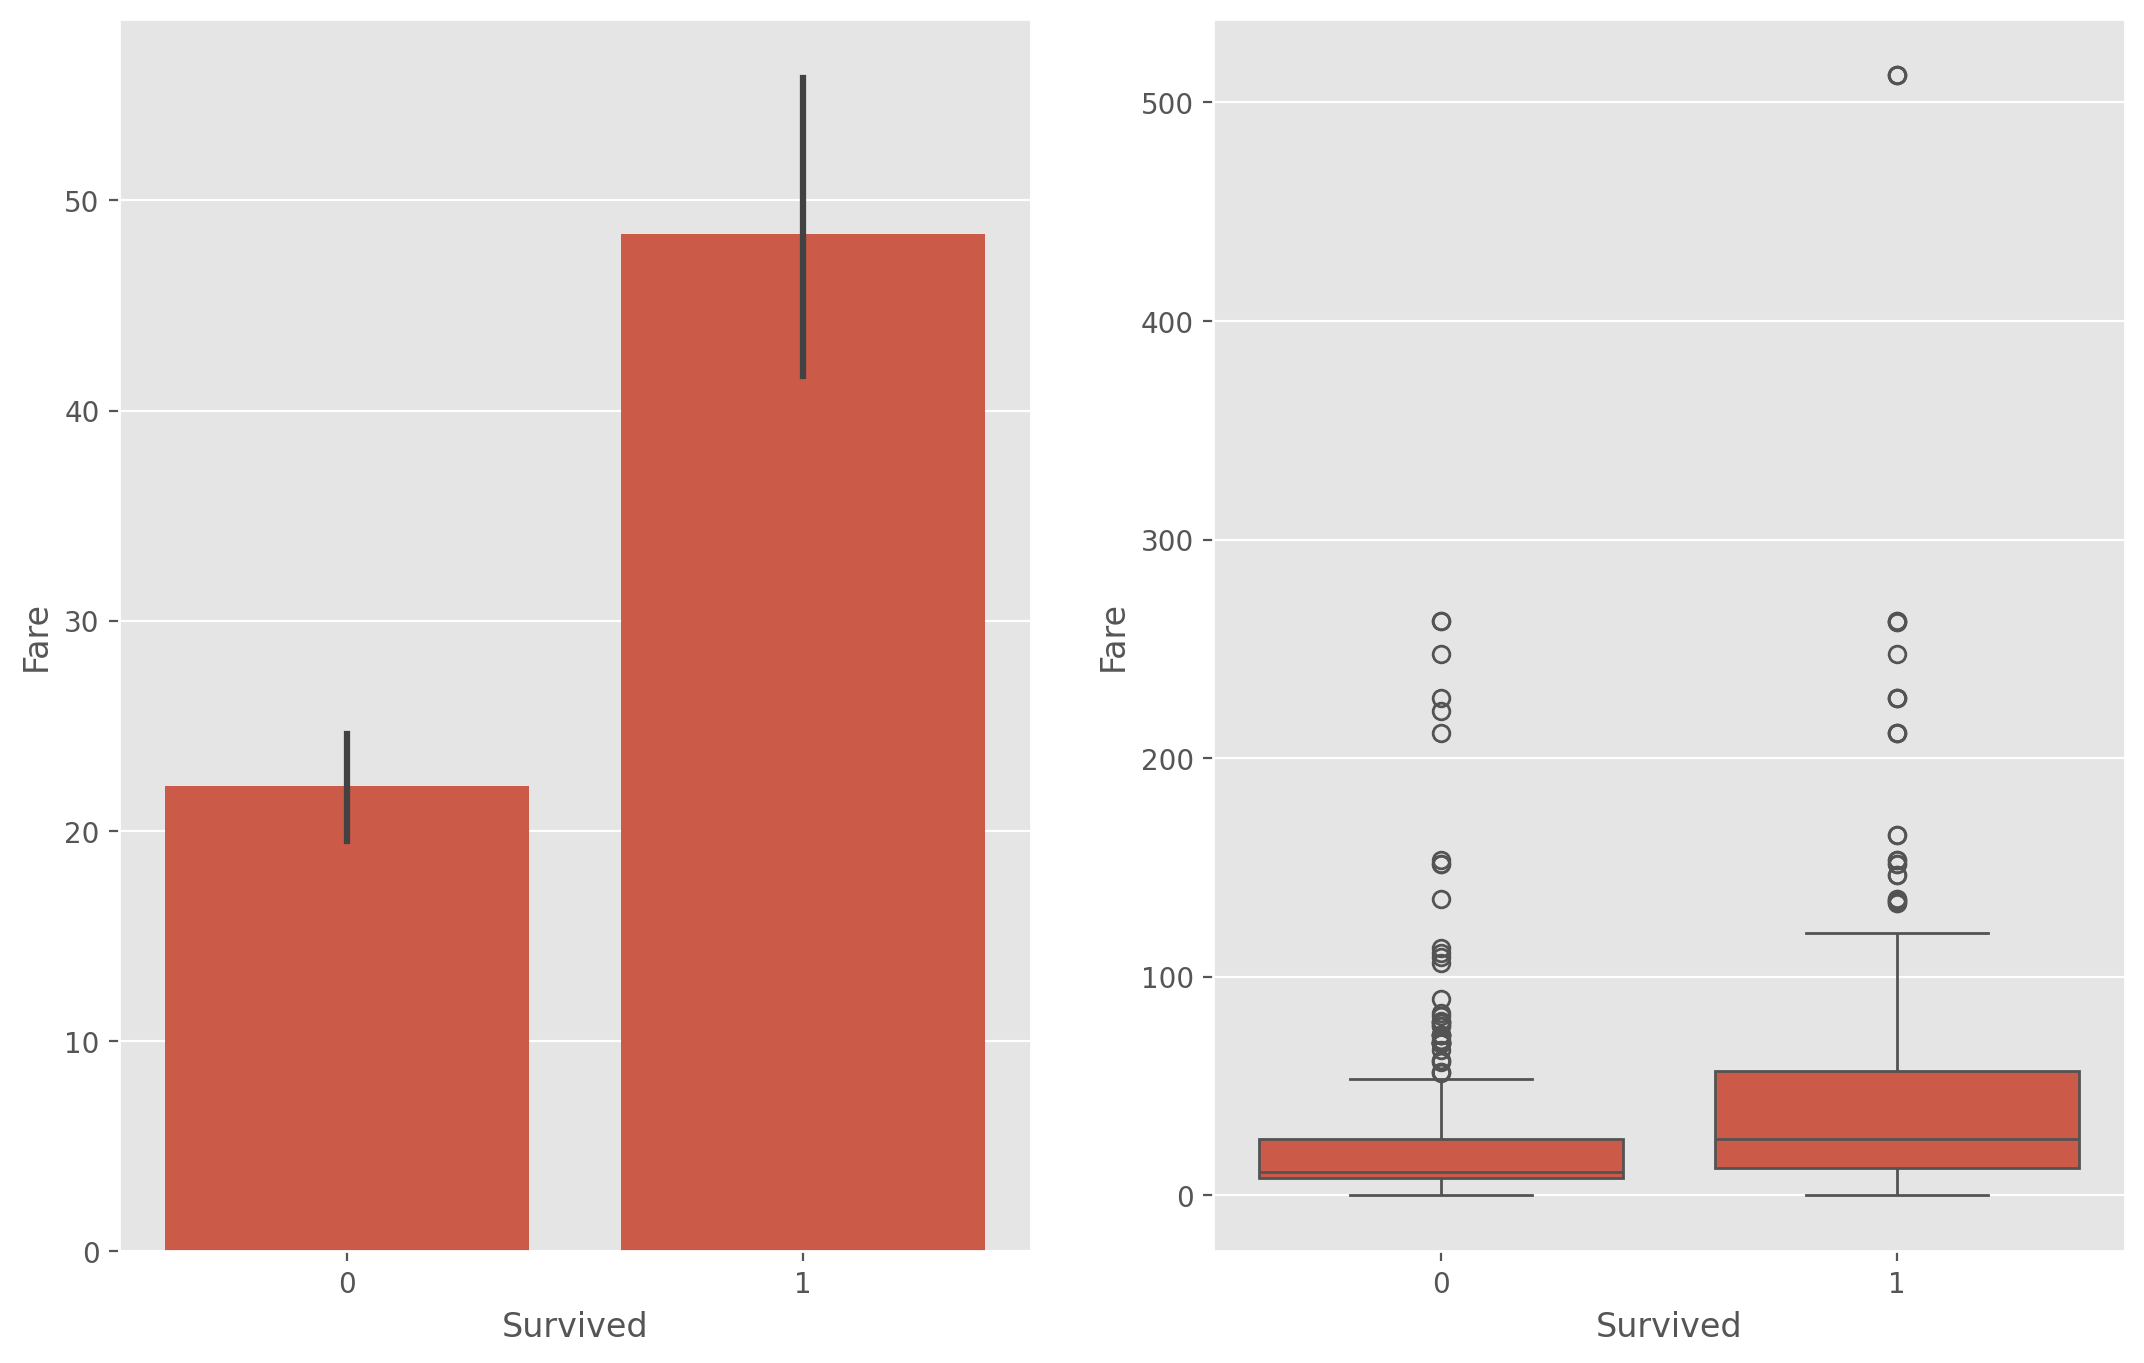

In [ ]:
plt.figure(figsize=(20,8),dpi=200)
plt.subplot(1,3,1)
sns.barplot(x='Survived',y='Fare',data=tdata)
plt.subplot(1,3,2)
sns.boxplot(x='Survived',y='Fare',data=tdata)


In [ ]:
#age and survival
tdata.groupby('Survived').Age.mean()


,Age
Survived,
0,30.415100
1,28.549778


<Axes: xlabel='Survived', ylabel='Age'>

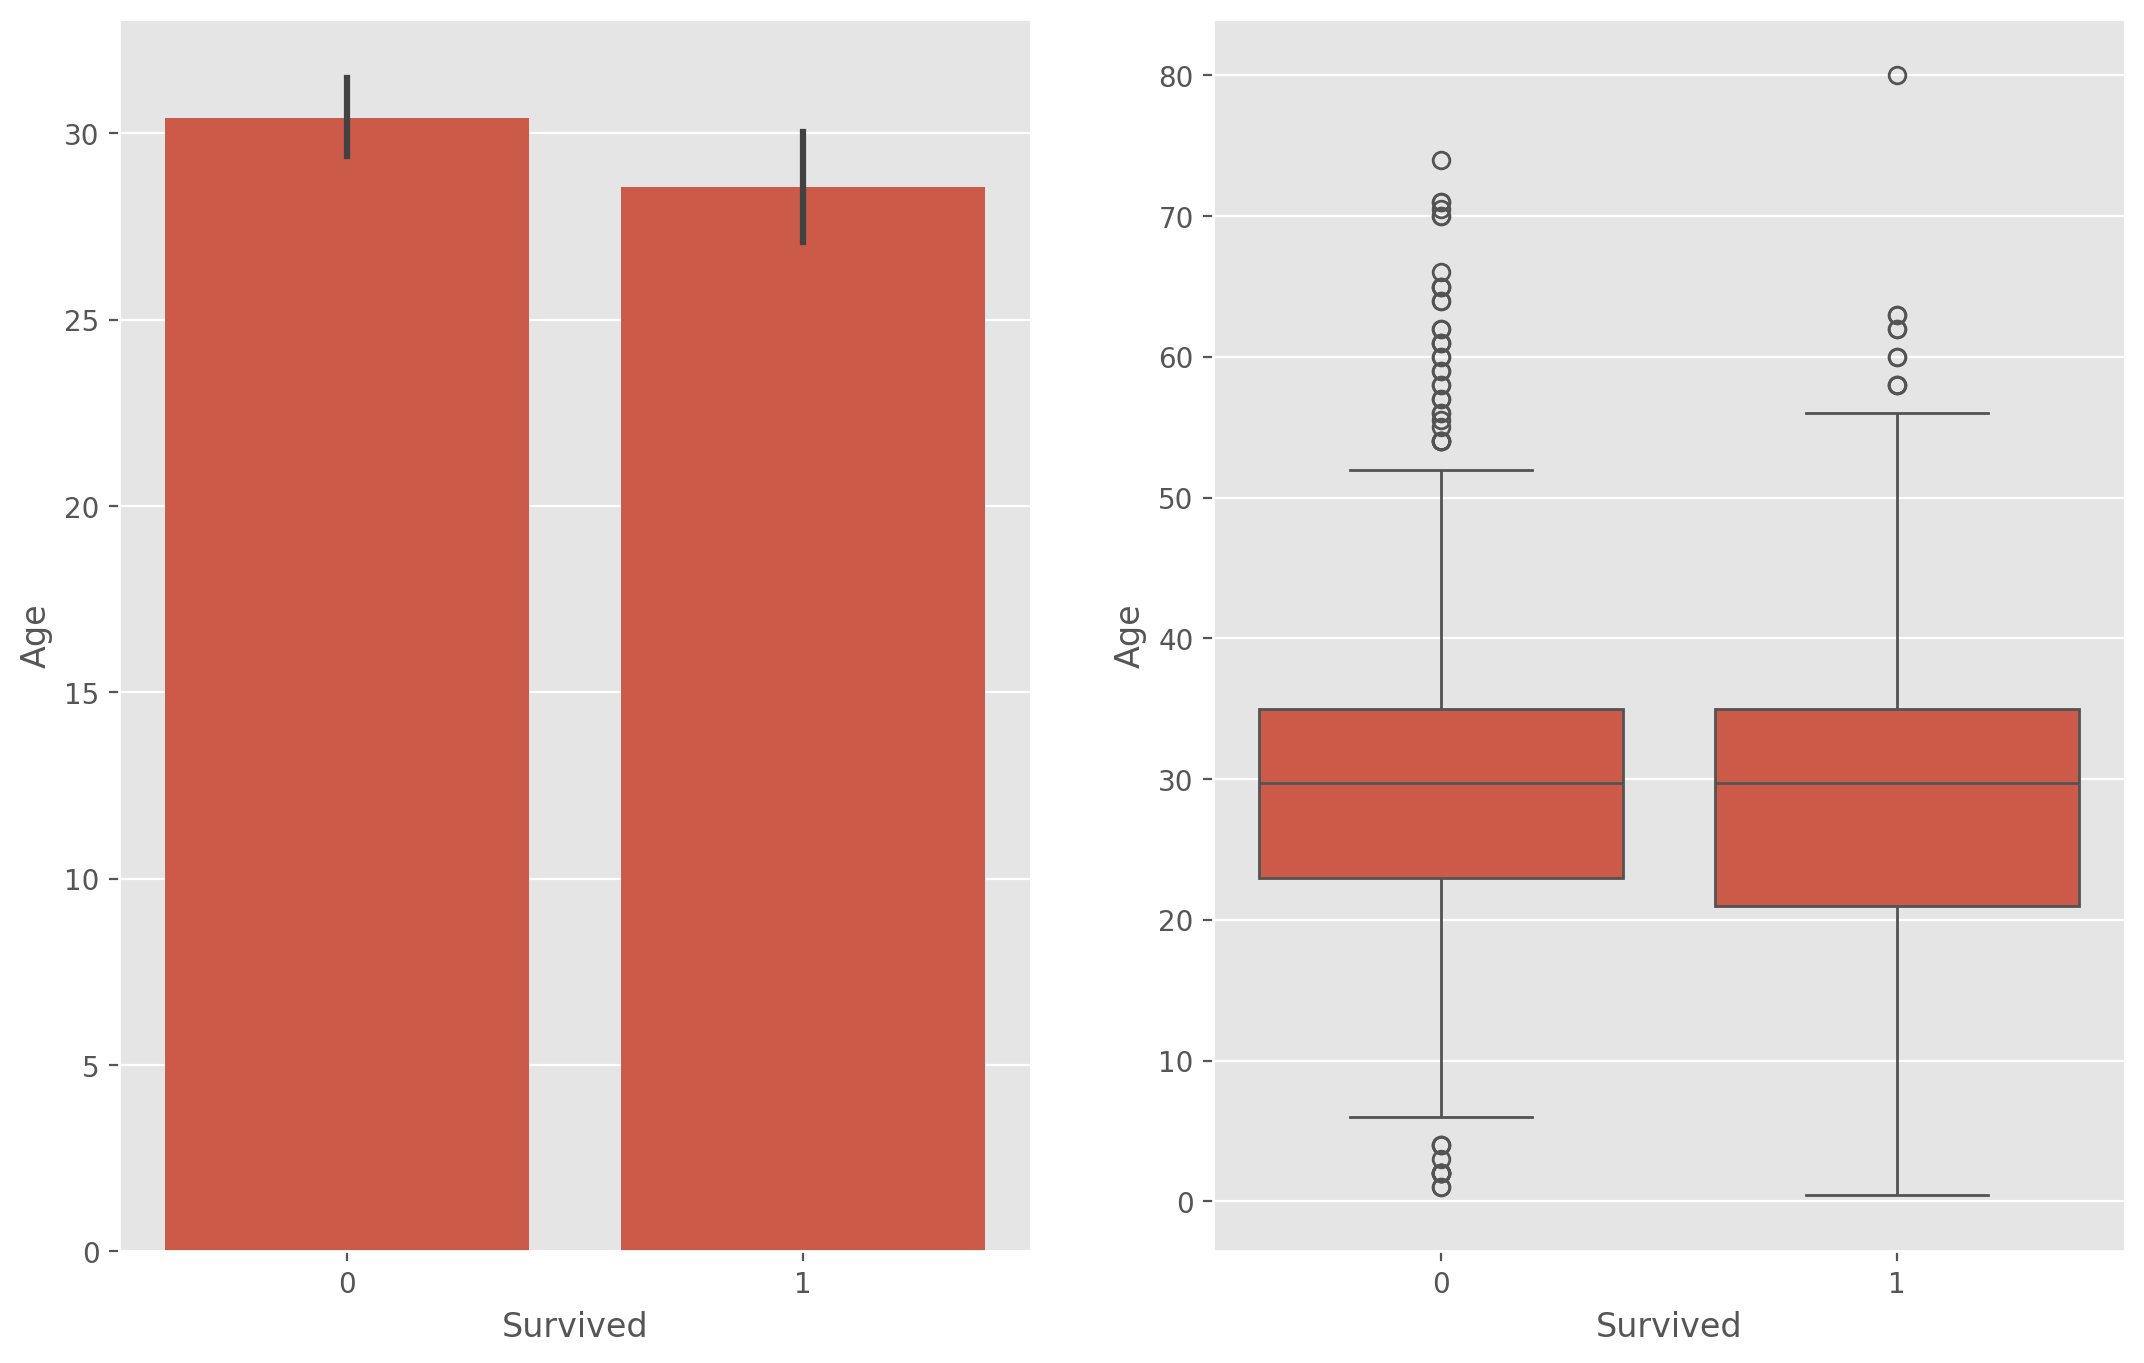

In [ ]:
plt.figure(figsize=(20,8),dpi=200)
plt.subplot(1,3,1)
sns.barplot(x='Survived',y='Age',data=tdata)
plt.subplot(1,3,2)
sns.boxplot(x='Survived',y='Age',data=tdata)
